# NN vs CNN on the same MNIST dataset
This notebook investigates how architecture and hyperparameter choices affect learning dynamics in a from-scratch (NumPy-only) neural network trained on MNIST, then compares it against a convolutional network(also built from scratch using only numpy) built with the same primitives. Each design choice(learning rate, activation function, weight initialization, network width, and depth) is tested in isolation and its effect on convergence, stability, and final accuracy is measured.

In [31]:
TRAIN_IMAGES_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte'
TRAIN_LABELS_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte'
TEST_IMAGES_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte'
TEST_LABELS_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte'
OUTPUT_PATH = '/kaggle/working'

Training Images : (60000, 784)
Training Labels : (60000,)
Testing Images  : (10000, 784)
Testing Labels  : (10000,)


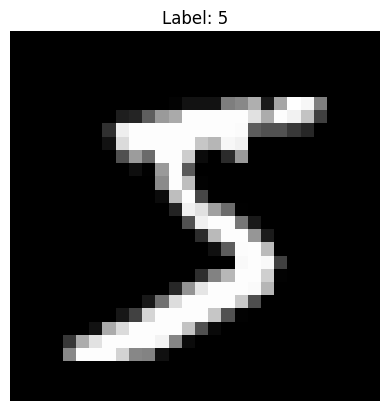

In [32]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

def load_images(file_path):
    with open(file_path, "rb") as f: #open file
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16)) #read header
        images = np.frombuffer(f.read(), dtype=np.uint8) #rd image data - all pixel values
        images = images.reshape(num_images, rows * cols) # reshape
        images = images.astype(np.float32) / 255.0 #normalize 
    return images

def load_labels(file_path):
    with open(file_path, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

#load the dataset
X_train = load_images(TRAIN_IMAGES_PATH)
y_train = load_labels(TRAIN_LABELS_PATH)
X_test = load_images(TEST_IMAGES_PATH)
y_test = load_labels(TEST_LABELS_PATH)
#verify and display one image to be sure
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

**ReLU:** ReLU (`max(0, z)`) is used because it helps with the vanishing-gradient problem that can happen with sigmoid and tanh. Its gradient is either 0 or 1, so it usually allows the gradients to pass through the network better. Also, if we only used linear activation functions, adding more layers would not really make the network more powerful because multiple linear layers can be combined into one linear transformation.

**Softmax:** Softmax is used in the output layer because we have 10 different classes and only one class should be the final prediction. It converts the outputs into probabilities that are positive and add up to 1. Using sigmoid for each output would treat the 10 classes separately, so the outputs would not necessarily add up to 1.

**Cross-entropy:** Cross-entropy is used with softmax because it works well for classification problems. When they are used together, the gradient becomes `Y_hat - Y_true`, which makes the backward pass much simpler. This also avoids having to calculate the full softmax gradient separately.

**He initialization:** He initialization is used because the network uses ReLU. It initializes the weights using `sqrt(2/n_in)`, which helps keep the values and gradients at a reasonable size. If the weights are too small, learning can become very slow, while weights that are too large can make training unstable.


In [33]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -500, 500)  # avoid overflow
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

ACTIVATIONS = {
    "relu":    (relu, relu_derivative),
    "sigmoid": (sigmoid, sigmoid_derivative),
    "tanh":    (tanh, tanh_derivative),
}

In [34]:
def compute_loss(Y_true, Y_pred):
    m = Y_true.shape[0]
    return -np.sum(Y_true * np.log(Y_pred + 1e-8)) / m

def one_hot_encode(labels, num_classes=10):
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1
    return one_hot

Y_train = one_hot_encode(y_train)
Y_test = one_hot_encode(y_test)
print(Y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [35]:
def initialize_parameters(layer_sizes, method="he", seed=42):
    #layer_sizes = [input, hidden1, hidden2, ..., output]
    np.random.seed(seed)
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        if method == "he":
            scale = np.sqrt(2.0 / n_in)
        elif method == "xavier":
            scale = np.sqrt(1.0 / n_in)
        elif method == "random":
            scale = 0.01
        else:
            raise ValueError(f"Unknown init method: {method}")
        W = np.random.randn(n_in, n_out) * scale
        b = np.zeros((1, n_out))
        params.append({"W": W, "b": b})
    return params

In [36]:
def forward(X, params, activation="relu"):
    act_fn, _ = ACTIVATIONS[activation]
    L = len(params)
    A = X
    cache = {"Z": [], "A": [X]}   # A[0] = input, A[L] = Y_hat
    for i, layer in enumerate(params):
        Z = A @ layer["W"] + layer["b"]
        A = softmax(Z) if i == L - 1 else act_fn(Z)
        cache["Z"].append(Z)
        cache["A"].append(A)
    return A, cache   # A is Y_hat

In [37]:
def backward(Y_true, cache, params, activation="relu"):
    _, act_deriv = ACTIVATIONS[activation]
    L = len(params)
    m = Y_true.shape[0]
    grads = [None] * L

    dZ = cache["A"][L] - Y_true  # softmax + cross-entropy simplification
    for i in reversed(range(L)):
        A_prev = cache["A"][i]
        dW = (A_prev.T @ dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m
        grads[i] = {"dW": dW, "db": db}
        if i > 0:
            dA_prev = dZ @ params[i]["W"].T
            dZ = dA_prev * act_deriv(cache["Z"][i - 1])
    return grads

def update_parameters(params, grads, learning_rate):
    for layer, grad in zip(params, grads):
        layer["W"] -= learning_rate * grad["dW"]
        layer["b"] -= learning_rate * grad["db"]
    return params

def predict(X, params, activation="relu"):
    Y_hat, _ = forward(X, params, activation)
    return np.argmax(Y_hat, axis=1)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [38]:
def train_nn(X_train, Y_train, y_train, X_test, y_test, hidden_sizes=[128], activation="relu", init_method="he",
             lr=0.1, epochs=10, batch_size=50, seed=42, verbose=True):

    layer_sizes = [X_train.shape[1]] + hidden_sizes + [Y_train.shape[1]]
    params = initialize_parameters(layer_sizes, method=init_method, seed=seed)
    num_samples = X_train.shape[0]
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        idx = np.random.permutation(num_samples)
        X_shuf, Y_shuf = X_train[idx], Y_train[idx]
        epoch_loss, n_batches = 0, 0

        for i in range(0, num_samples, batch_size):
            X_batch = X_shuf[i:i + batch_size]
            Y_batch = Y_shuf[i:i + batch_size]
            Y_hat, cache = forward(X_batch, params, activation)
            epoch_loss += compute_loss(Y_batch, Y_hat)
            n_batches += 1
            grads = backward(Y_batch, cache, params, activation)
            params = update_parameters(params, grads, lr)

        epoch_loss /= n_batches
        train_acc = accuracy(y_train, predict(X_train, params, activation))
        test_acc = accuracy(y_test, predict(X_test, params, activation))

        history["loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs}: loss={epoch_loss:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    return params, history

## Baseline Model
A 784→128→10 network, He-initialized, ReLU hidden activation, softmax output, lr=0.1, batch size 50, 10 epochs. This configuration is the fixed reference point every later experiment is compared against.

In [39]:
params, history = train_nn( X_train, Y_train, y_train, X_test, y_test, hidden_sizes=[128], activation="relu", 
                           init_method="he", lr=0.1, epochs=10, batch_size=50)

Epoch 1/10: loss=0.3475, train_acc=0.9365, test_acc=0.9368
Epoch 2/10: loss=0.1776, train_acc=0.9611, test_acc=0.9575
Epoch 3/10: loss=0.1294, train_acc=0.9711, test_acc=0.9675
Epoch 4/10: loss=0.1031, train_acc=0.9762, test_acc=0.9706
Epoch 5/10: loss=0.0862, train_acc=0.9803, test_acc=0.9753
Epoch 6/10: loss=0.0734, train_acc=0.9813, test_acc=0.9744
Epoch 7/10: loss=0.0642, train_acc=0.9846, test_acc=0.9754
Epoch 8/10: loss=0.0570, train_acc=0.9877, test_acc=0.9779
Epoch 9/10: loss=0.0505, train_acc=0.9875, test_acc=0.9760
Epoch 10/10: loss=0.0462, train_acc=0.9903, test_acc=0.9786


The baseline reaches 97.86% test accuracy by epoch 10, with train accuracy (99.03%) slightly ahead of test accuracy which is expected generalization gap rather than 
overfitting, given the gap stays under 1.2 points.


## Learning Rate

In [40]:
# results of different learning rates
lr_results = {}
for lr in [0.01, 0.001]:
    print(f"Learning Rate: {lr}")
    _, hist = train_nn(X_train, Y_train, y_train, X_test, y_test, lr=lr, verbose=True)
    lr_results[f"lr={lr}"] = hist

Learning Rate: 0.01
Epoch 1/10: loss=0.7913, train_acc=0.8822, test_acc=0.8908
Epoch 2/10: loss=0.3849, train_acc=0.9030, test_acc=0.9083
Epoch 3/10: loss=0.3279, train_acc=0.9126, test_acc=0.9180
Epoch 4/10: loss=0.2969, train_acc=0.9207, test_acc=0.9249
Epoch 5/10: loss=0.2748, train_acc=0.9259, test_acc=0.9290
Epoch 6/10: loss=0.2572, train_acc=0.9306, test_acc=0.9319
Epoch 7/10: loss=0.2425, train_acc=0.9347, test_acc=0.9354
Epoch 8/10: loss=0.2294, train_acc=0.9387, test_acc=0.9390
Epoch 9/10: loss=0.2178, train_acc=0.9412, test_acc=0.9416
Epoch 10/10: loss=0.2075, train_acc=0.9442, test_acc=0.9433
Learning Rate: 0.001
Epoch 1/10: loss=1.8979, train_acc=0.6830, test_acc=0.6932
Epoch 2/10: loss=1.2366, train_acc=0.7833, test_acc=0.7985
Epoch 3/10: loss=0.8969, train_acc=0.8261, test_acc=0.8387
Epoch 4/10: loss=0.7243, train_acc=0.8468, test_acc=0.8589
Epoch 5/10: loss=0.6260, train_acc=0.8594, test_acc=0.8691
Epoch 6/10: loss=0.5632, train_acc=0.8666, test_acc=0.8766
Epoch 7/10: lo

At lr=0.1 the network reaches 97.86% by epoch 10. At lr=0.01, it only reaches 94.33% in the same 10 epochs, and the curve is still rising( as seen in the graph below) - it hasn't converged, just slowed down. At lr=0.001, it reaches only 89.11% and is clearly under-trained at 10 epochs. Lower learning rates aren't unstable here as we can see that they are too slow to converge within a fixed compute budget.

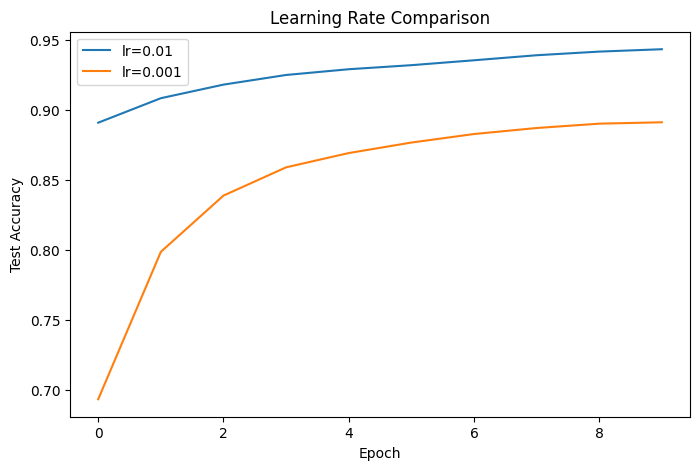

In [41]:
# LR comparison plot
plt.figure(figsize=(8,5))
for name, hist in lr_results.items():
    plt.plot(hist["test_acc"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy")
plt.title("Learning Rate Comparison"); plt.legend(); plt.show()

## Network Depth

In [42]:
# results of different depth of network
depth_results = {}
for hidden_sizes in [[128], [128, 64], [128, 64, 32]]:
    _, hist = train_nn(X_train, Y_train, y_train, X_test, y_test, hidden_sizes=hidden_sizes, verbose=True)
    depth_results[f"depth={len(hidden_sizes)}"] = hist

Epoch 1/10: loss=0.3475, train_acc=0.9365, test_acc=0.9368
Epoch 2/10: loss=0.1776, train_acc=0.9611, test_acc=0.9575
Epoch 3/10: loss=0.1294, train_acc=0.9711, test_acc=0.9675
Epoch 4/10: loss=0.1031, train_acc=0.9762, test_acc=0.9706
Epoch 5/10: loss=0.0862, train_acc=0.9803, test_acc=0.9753
Epoch 6/10: loss=0.0734, train_acc=0.9813, test_acc=0.9744
Epoch 7/10: loss=0.0642, train_acc=0.9846, test_acc=0.9754
Epoch 8/10: loss=0.0570, train_acc=0.9877, test_acc=0.9779
Epoch 9/10: loss=0.0505, train_acc=0.9875, test_acc=0.9760
Epoch 10/10: loss=0.0462, train_acc=0.9903, test_acc=0.9786
Epoch 1/10: loss=0.3053, train_acc=0.9568, test_acc=0.9535
Epoch 2/10: loss=0.1360, train_acc=0.9707, test_acc=0.9647
Epoch 3/10: loss=0.0986, train_acc=0.9772, test_acc=0.9694
Epoch 4/10: loss=0.0770, train_acc=0.9813, test_acc=0.9704
Epoch 5/10: loss=0.0630, train_acc=0.9842, test_acc=0.9731
Epoch 6/10: loss=0.0515, train_acc=0.9894, test_acc=0.9731
Epoch 7/10: loss=0.0418, train_acc=0.9910, test_acc=0.9

1 hidden layer ([128]) reaches 97.86% test accuracy, 2 hidden layers ([128,64]) reach 97.72%, and 3 hidden layers ([128,64,32]) reach 97.88%. These results are within 0.16 percentage points of each other, which is too small a spread to call a real trend, and not monotonic in either direction. At this scale (a few hundred thousand parameters, 10 epochs, plain SGD), adding depth neither helps nor hurts: MNIST digit classification doesn't require the additional representational capacity extra layers provide, so the network isn't depth-limited. This is itself informative as it suggests any accuracy gains would need to come from other levers such as training on more data, having wider layers, or better optimization and not from stacking more layers onto an architecture that is already sufficient.

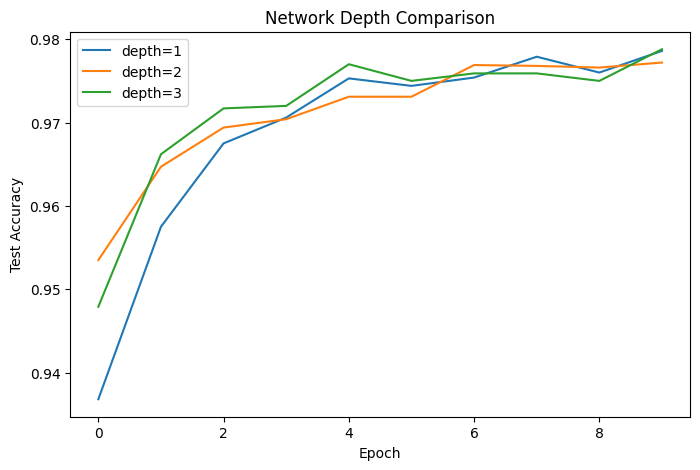

In [43]:
# Depth comparison plot
plt.figure(figsize=(8,5))
for name, hist in depth_results.items():
    plt.plot(hist["test_acc"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy")
plt.title("Network Depth Comparison"); plt.legend(); plt.show()

## Activation Function Comparison

In [44]:
activation_results = {}
for act in ["relu", "sigmoid", "tanh"]:
    print(f"Activation: {act}")
    _, hist = train_nn(X_train, Y_train, y_train, X_test, y_test, activation=act, verbose=True)
    activation_results[act] = hist

Activation: relu
Epoch 1/10: loss=0.3475, train_acc=0.9365, test_acc=0.9368
Epoch 2/10: loss=0.1776, train_acc=0.9611, test_acc=0.9575
Epoch 3/10: loss=0.1294, train_acc=0.9711, test_acc=0.9675
Epoch 4/10: loss=0.1031, train_acc=0.9762, test_acc=0.9706
Epoch 5/10: loss=0.0862, train_acc=0.9803, test_acc=0.9753
Epoch 6/10: loss=0.0734, train_acc=0.9813, test_acc=0.9744
Epoch 7/10: loss=0.0642, train_acc=0.9846, test_acc=0.9754
Epoch 8/10: loss=0.0570, train_acc=0.9877, test_acc=0.9779
Epoch 9/10: loss=0.0505, train_acc=0.9875, test_acc=0.9760
Epoch 10/10: loss=0.0462, train_acc=0.9903, test_acc=0.9786
Activation: sigmoid
Epoch 1/10: loss=0.6380, train_acc=0.8947, test_acc=0.8991
Epoch 2/10: loss=0.3317, train_acc=0.9129, test_acc=0.9163
Epoch 3/10: loss=0.2893, train_acc=0.9213, test_acc=0.9249
Epoch 4/10: loss=0.2618, train_acc=0.9302, test_acc=0.9320
Epoch 5/10: loss=0.2399, train_acc=0.9358, test_acc=0.9358
Epoch 6/10: loss=0.2207, train_acc=0.9405, test_acc=0.9401
Epoch 7/10: loss=0

ReLU reaches 97.86% by epoch 10, sigmoid reaches 95.25%, and tanh reaches 97.51%. 

Sigmoid is clearly behind the other two, and consistently behind at every epoch, not just the early ones. This is a visible instance of the vanishing-gradient problem discussed above: sigmoid's gradient saturates for large |z|, so weight updates shrink and learning slows, even over just 10 epochs. Tanh, by contrast, is only 0.35 points behind ReLU and tracks its curve closely - being zero-centered (unlike sigmoid, which outputs only positive values), anh avoids some of sigmoid's saturation issues and gets closer to ReLU's convergence rate, though it still hasn't quite caught up by epoch 10.

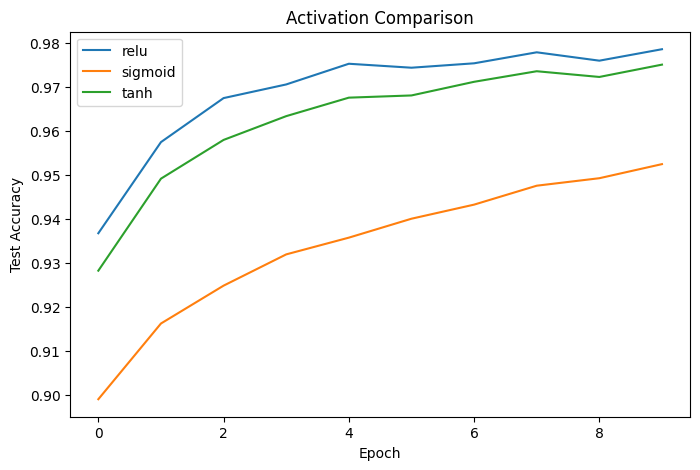

In [45]:
# Activation plot
plt.figure(figsize=(8,5))
for name, hist in activation_results.items():
    plt.plot(hist["test_acc"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy")
plt.title("Activation Comparison"); plt.legend(); plt.show()

## Weight Initialization Comparison

In [46]:
init_results = {}
for method in ["random", "xavier", "he"]:
    _, hist = train_nn(X_train, Y_train, y_train, X_test, y_test, init_method=method, verbose=True)
    init_results[method] = hist

Epoch 1/10: loss=0.4918, train_acc=0.9215, test_acc=0.9227
Epoch 2/10: loss=0.2170, train_acc=0.9516, test_acc=0.9486
Epoch 3/10: loss=0.1592, train_acc=0.9639, test_acc=0.9587
Epoch 4/10: loss=0.1263, train_acc=0.9705, test_acc=0.9647
Epoch 5/10: loss=0.1048, train_acc=0.9756, test_acc=0.9691
Epoch 6/10: loss=0.0886, train_acc=0.9781, test_acc=0.9707
Epoch 7/10: loss=0.0770, train_acc=0.9800, test_acc=0.9713
Epoch 8/10: loss=0.0683, train_acc=0.9850, test_acc=0.9765
Epoch 9/10: loss=0.0602, train_acc=0.9846, test_acc=0.9751
Epoch 10/10: loss=0.0547, train_acc=0.9867, test_acc=0.9772
Epoch 1/10: loss=0.3712, train_acc=0.9325, test_acc=0.9335
Epoch 2/10: loss=0.1874, train_acc=0.9586, test_acc=0.9571
Epoch 3/10: loss=0.1362, train_acc=0.9698, test_acc=0.9666
Epoch 4/10: loss=0.1082, train_acc=0.9744, test_acc=0.9685
Epoch 5/10: loss=0.0904, train_acc=0.9794, test_acc=0.9730
Epoch 6/10: loss=0.0770, train_acc=0.9805, test_acc=0.9738
Epoch 7/10: loss=0.0669, train_acc=0.9833, test_acc=0.9

Random init (scale 0.01) reaches 97.72%, Xavier reaches 97.83%, He reaches 97.86%. He initialization is calibrated for ReLU's non-linearity, so it typically converges fastest here; random init with a fixed small scale ignores layer width entirely, which becomes a bigger handicap as layers grow.

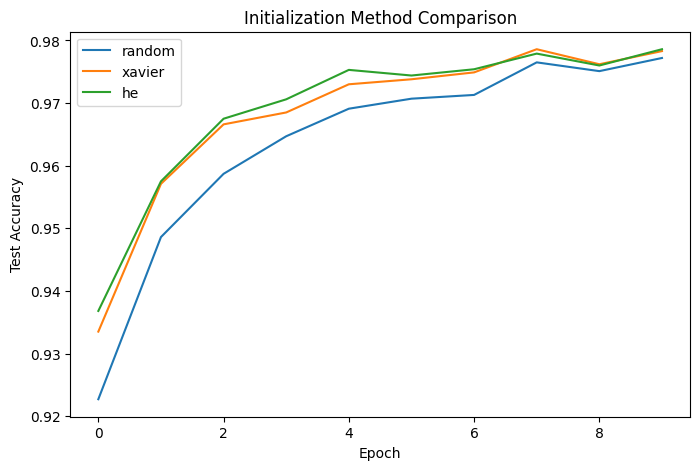

In [47]:
# Initialization method
plt.figure(figsize=(8,5))
for name, hist in init_results.items():
    plt.plot(hist["test_acc"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy")
plt.title("Initialization Method Comparison"); plt.legend(); plt.show()

## Hidden Layer Width

In [48]:
# Hidden Width
width_results = {}
for h in [64, 128, 256, 512]:
    print(f"Hidden Width: {h}")
    _, hist = train_nn(X_train, Y_train, y_train, X_test, y_test, hidden_sizes=[h], verbose=True)
    width_results[f"hidden={h}"] = hist

Hidden Width: 64
Epoch 1/10: loss=0.3556, train_acc=0.9381, test_acc=0.9396
Epoch 2/10: loss=0.1943, train_acc=0.9557, test_acc=0.9534
Epoch 3/10: loss=0.1478, train_acc=0.9655, test_acc=0.9610
Epoch 4/10: loss=0.1213, train_acc=0.9706, test_acc=0.9651
Epoch 5/10: loss=0.1041, train_acc=0.9742, test_acc=0.9678
Epoch 6/10: loss=0.0904, train_acc=0.9746, test_acc=0.9663
Epoch 7/10: loss=0.0805, train_acc=0.9795, test_acc=0.9712
Epoch 8/10: loss=0.0726, train_acc=0.9818, test_acc=0.9708
Epoch 9/10: loss=0.0657, train_acc=0.9839, test_acc=0.9721
Epoch 10/10: loss=0.0601, train_acc=0.9857, test_acc=0.9732
Hidden Width: 128
Epoch 1/10: loss=0.3475, train_acc=0.9365, test_acc=0.9368
Epoch 2/10: loss=0.1776, train_acc=0.9611, test_acc=0.9575
Epoch 3/10: loss=0.1294, train_acc=0.9711, test_acc=0.9675
Epoch 4/10: loss=0.1031, train_acc=0.9762, test_acc=0.9706
Epoch 5/10: loss=0.0862, train_acc=0.9803, test_acc=0.9753
Epoch 6/10: loss=0.0734, train_acc=0.9813, test_acc=0.9744
Epoch 7/10: loss=0.0

64, 128, 256, and 512 hidden neurons reach 97.32%, 97.86%, 97.83%, and 98.06% test \accuracy respectively. Beyond 128 neurons, additional width gives us very little advantage. We can see that 256 neurons is almost indistinguishable from 128 (97.83% vs 97.86%), and 512 only adds another 0.2 points over 128 despite quadrupling the hidden layer size. The clearest jump is from 64 to 128 (+0.54 points); past that point the network already has enough capacity for this task, and doubling parameters repeatedly does not do us any benefit. Since training time wasn't measured directly here, this can't be stated as a measured compute/accuracy tradeoff, but each width doubling roughly doubles the matrix 
multiplication cost per forward and backward pass, so the diminishing accuracy return combined with the known linear compute cost is a reasonable basis to prefer a smaller network (128 or 256) over 512 for this task.

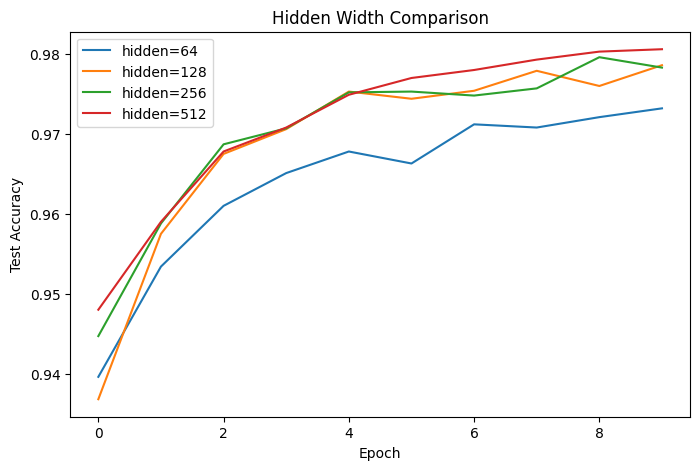

In [49]:
plt.figure(figsize=(8,5))
for name, hist in width_results.items():
    plt.plot(hist["test_acc"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy")
plt.title("Hidden Width Comparison"); plt.legend(); plt.show()

## Confusion Matrix and Per-Class Metrics

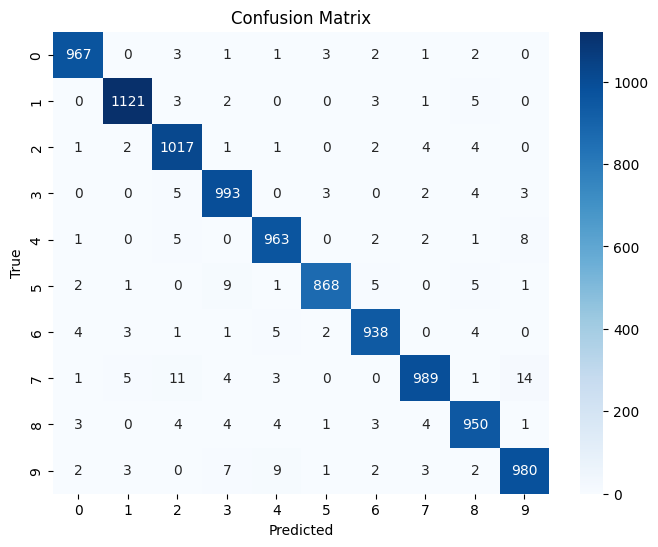

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [50]:
# confusion matrix and metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_preds = predict(X_test, params, activation="relu") 
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, test_preds))

Overall test accuracy is 98%, with precision and recall staying at 0.97+ for every digit. The lowest-performing classes are 7, 8, and 9 (F1 = 0.97), consistent with the classic MNIST confusions where these digits share strokes with 1, 3, and 4.

## Misclassified Examples

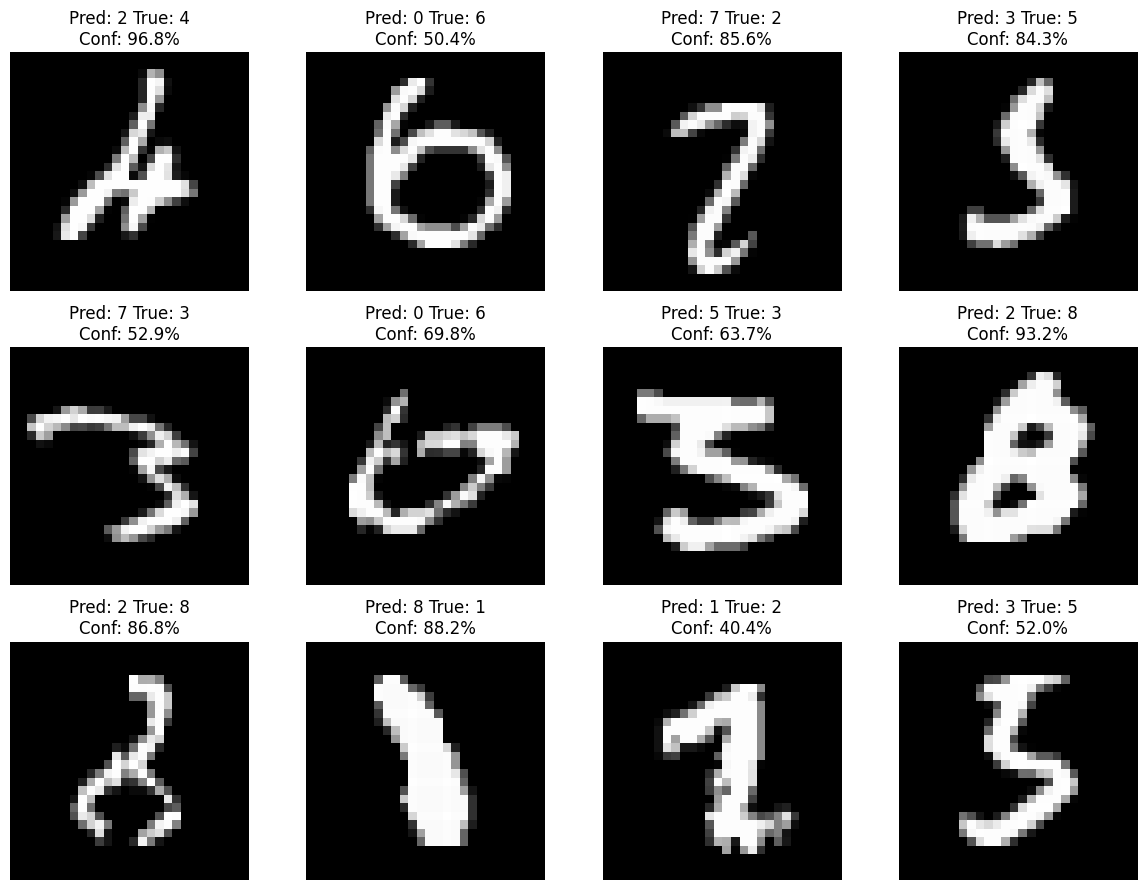

In [51]:
Y_hat_test, _ = forward(X_test, params, activation="relu")
test_preds = np.argmax(Y_hat_test, axis=1)
confidences = np.max(Y_hat_test, axis=1)
wrong_idx = np.where(test_preds != y_test)[0][:12]

fig, axes = plt.subplots(3, 4, figsize=(12,9))
for ax, idx in zip(axes.flat, wrong_idx):
    ax.imshow(X_test[idx].reshape(28,28), cmap="gray")
    ax.set_title(f"Pred: {test_preds[idx]} True: {y_test[idx]}\nConf: {confidences[idx]*100:.1f}%")
    ax.axis("off")
plt.tight_layout(); plt.show()

 Misclassifications generally fall into two groups: low-confidence errors on genuinely ambiguous handwriting, where 
the true and predicted digits share visual structure, and a smaller number of high-confidence wrong predictions, where the model is confidently mistaken rather than uncertain — these are the more concerning failure mode since low confidence at least signals uncertainty downstream.

# letter predictions

In [52]:
from PIL import Image

def preprocess_image(path):
    img = Image.open(path)
    img = img.convert("L")# grayscale
    img = img.resize((28,28))
    img = np.array(img)
    img = 255 - img
    img = img.astype(np.float32) / 255.0
    img = img.reshape(1,784)
    return img

In [53]:
# Uses params from the baseline run (hidden_sizes=[128], activation="relu")
letters = ["a", "c", "d", "e", "f", "g", "i", "m", "n", "p", "x", "z"]

for letter in letters:
    path = f"/kaggle/input/datasets/fatima0106/letters/{letter}.png"
    image = preprocess_image(path)
    probabilities, _ = forward(image, params, activation="relu")
    prediction = np.argmax(probabilities, axis=1)[0]
    confidence = np.max(probabilities) * 100
    print(f"Letter: {letter} --> Predicted Digit: {prediction} ({confidence:.2f}%)")

Letter: a --> Predicted Digit: 4 (53.77%)
Letter: c --> Predicted Digit: 2 (30.96%)
Letter: d --> Predicted Digit: 2 (77.36%)
Letter: e --> Predicted Digit: 2 (97.74%)
Letter: f --> Predicted Digit: 2 (89.34%)
Letter: g --> Predicted Digit: 9 (95.49%)
Letter: i --> Predicted Digit: 2 (91.54%)
Letter: m --> Predicted Digit: 4 (99.34%)
Letter: n --> Predicted Digit: 7 (85.99%)
Letter: p --> Predicted Digit: 8 (47.81%)
Letter: x --> Predicted Digit: 2 (39.70%)
Letter: z --> Predicted Digit: 2 (99.23%)


None of the 12 letters are classified with meaningful accuracy, which is expected as the model was never trained on any class outside 0–9, so there's no correct answer to check against. What's notable is that several letters produce high-confidence wrong predictions (e.g. 'z' at 99.23% confidence, 'm' at 99.34%) rather than low-confidence ones — the softmax output is confident even when the input is entirely out-of-distribution, which is a known limitation of softmax classifiers: confidence reflects relative likelihood among the 10 trained classes, not whether the input belongs to any of them at all.

## Convolutional Neural Network (from scratch)
Built with the same primitives (ReLU, softmax, cross-entropy) but adding convolution and max-pooling layers, implemented via `im2col`/`col2im` for vectorized batch processing rather than naive nested loops.

In [54]:
def im2col_batch(input_maps, f_h, f_w):
    # input_maps: (batch, C, H, W)  ->  cols: (batch, C*f_h*f_w, out_h*out_w)
    batch, C, H, W = input_maps.shape
    out_h = H - f_h + 1
    out_w = W - f_w + 1

    s0, s1, s2, s3 = input_maps.strides
    shape = (batch, C, out_h, out_w, f_h, f_w)
    strides = (s0, s1, s2, s3, s2, s3)
    patches = np.lib.stride_tricks.as_strided(input_maps, shape=shape, strides=strides)

    patches = patches.transpose(0, 1, 4, 5, 2, 3)
    cols = patches.reshape(batch, C * f_h * f_w, out_h * out_w)
    return cols, out_h, out_w

def col2im_batch(d_cols, input_shape, f_h, f_w):
    # d_cols: (batch, C*f_h*f_w, out_h*out_w)  ->  d_input: (batch, C, H, W)
    batch, C, H, W = input_shape
    out_h = H - f_h + 1
    out_w = W - f_w + 1

    d_input = np.zeros((batch, C, H, W))
    d_cols_r = d_cols.reshape(batch, C, f_h, f_w, out_h, out_w)

    for di in range(f_h):
        for dj in range(f_w):
            d_input[:, :, di:di+out_h, dj:dj+out_w] += d_cols_r[:, :, di, dj, :, :]

    return d_input

def conv_multichannel(input_maps, filters, biases):
    # input_maps: (batch, C, H, W), filters: (num_filters, C, f_h, f_w)
    num_filters, in_channels, f_h, f_w = filters.shape

    cols, out_h, out_w = im2col_batch(input_maps, f_h, f_w) 
    filters_flat = filters.reshape(num_filters, -1)      

    output = np.einsum('fk,bkp->bfp', filters_flat, cols) 
    output = output.reshape(-1, num_filters, out_h, out_w)
    output += biases.reshape(1, num_filters, 1, 1)

    return output

def conv_multichannel_backward(d_out, input_maps, filters):
    # d_out: (batch, num_filters, out_h, out_w), input_maps: (batch, C, H, W)
    num_filters, in_channels, f_h, f_w = filters.shape
    batch, C, H, W = input_maps.shape

    cols, out_h, out_w = im2col_batch(input_maps, f_h, f_w)
    filters_flat = filters.reshape(num_filters, -1)     
    d_out_flat = d_out.reshape(batch, num_filters, out_h * out_w)

    # gradient w.r.t filters summed across the whole batch, like grads_sum used to be
    d_filters_flat = np.einsum('bfp,bkp->fk', d_out_flat, cols)
    d_filters = d_filters_flat.reshape(num_filters, in_channels, f_h, f_w)

    d_biases = d_out.sum(axis=(0, 2, 3))

    d_cols = np.einsum('fk,bfp->bkp', filters_flat, d_out_flat)
    d_input = col2im_batch(d_cols, (batch, C, H, W), f_h, f_w)

    return d_filters, d_biases, d_input

def maxpool_multi_forward(feature_maps, size=2, stride=2):
    # feature_maps: (batch, C, H, W)
    batch, C, H, W = feature_maps.shape
    out_h = (H - size) // stride + 1
    out_w = (W - size) // stride + 1

    s0, s1, s2, s3 = feature_maps.strides
    shape = (batch, C, out_h, out_w, size, size)
    strides = (s0, s1, s2 * stride, s3 * stride, s2, s3)
    windows = np.lib.stride_tricks.as_strided(feature_maps, shape=shape, strides=strides)
    windows = windows.reshape(batch, C, out_h, out_w, size * size)

    output = windows.max(axis=-1)
    max_idx = windows.argmax(axis=-1)   # (batch, C, out_h, out_w), flat index into window

    return output, max_idx

def maxpool_multi_backward(d_out, feature_maps_shape, max_idx, size=2, stride=2):
    batch, C, H, W = feature_maps_shape
    out_h, out_w = d_out.shape[2], d_out.shape[3]

    d_feature_maps = np.zeros((batch, C, H, W))

    di = max_idx // size
    dj = max_idx % size

    b_idx = np.arange(batch).reshape(batch, 1, 1, 1)
    c_idx = np.arange(C).reshape(1, C, 1, 1)
    i_idx = np.arange(out_h).reshape(1, 1, out_h, 1)
    j_idx = np.arange(out_w).reshape(1, 1, 1, out_w)

    row = i_idx * stride + di
    col = j_idx * stride + dj

    np.add.at(d_feature_maps, (b_idx, c_idx, row, col), d_out)

    return d_feature_maps

def cnn_forward(images, params):
    # images: (batch, 28, 28)
    filters1, biases1 = params["filters1"], params["biases1"]
    filters2, biases2 = params["filters2"], params["biases2"]
    W_fc, b_fc = params["W_fc"], params["b_fc"]

    batch = images.shape[0]
    img_input = images.reshape(batch, 1, 28, 28)

    Z1 = conv_multichannel(img_input, filters1, biases1)
    A1 = relu(Z1)
    P1, pos1 = maxpool_multi_forward(A1, size=2, stride=2)

    Z2 = conv_multichannel(P1, filters2, biases2)
    A2 = relu(Z2)
    P2, pos2 = maxpool_multi_forward(A2, size=2, stride=2)

    flat = P2.reshape(batch, -1)
    Z3 = flat @ W_fc + b_fc
    Y_hat = softmax(Z3)     # expects/returns shape (batch, 10)

    cache = {
        "img_input": img_input, "Z1": Z1, "A1": A1, "P1": P1, "pos1": pos1,
        "Z2": Z2, "A2": A2, "P2": P2, "pos2": pos2,
        "flat": flat, "Y_hat": Y_hat
    }
    return Y_hat, cache


def cnn_backward(Y_true_batch, cache, params):
    # Y_true_batch: (batch, 10)
    W_fc = params["W_fc"]
    filters1, filters2 = params["filters1"], params["filters2"]

    dZ3 = cache["Y_hat"] - Y_true_batch          # (batch, 10)
    dW_fc = cache["flat"].T @ dZ3                 # summed over batch already
    db_fc = dZ3.sum(axis=0, keepdims=True)
    d_flat = dZ3 @ W_fc.T

    dP2 = d_flat.reshape(cache["P2"].shape)
    dA2 = maxpool_multi_backward(dP2, cache["A2"].shape, cache["pos2"], size=2, stride=2)
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    d_filters2, d_biases2, dP1 = conv_multichannel_backward(dZ2, cache["P1"], filters2)

    dA1 = maxpool_multi_backward(dP1, cache["A1"].shape, cache["pos1"], size=2, stride=2)
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    d_filters1, d_biases1, _ = conv_multichannel_backward(dZ1, cache["img_input"], filters1)

    grads = {
        "d_filters1": d_filters1, "d_biases1": d_biases1,
        "d_filters2": d_filters2, "d_biases2": d_biases2,
        "dW_fc": dW_fc, "db_fc": db_fc
    }
    return grads

def initialize_cnn_params(num_filters1=8, num_filters2=16, kernel_size=3):
    np.random.seed(42)
    filters1 = np.random.randn(num_filters1, 1, kernel_size, kernel_size) * np.sqrt(2/(1*kernel_size*kernel_size))
    biases1 = np.zeros(num_filters1)
    filters2 = np.random.randn(num_filters2, num_filters1, kernel_size, kernel_size) * np.sqrt(2/(num_filters1*kernel_size*kernel_size))
    biases2 = np.zeros(num_filters2)

    dummy_img = np.zeros((1, 1, 28, 28))   # batch dim = 1
    z1 = conv_multichannel(dummy_img, filters1, biases1)
    p1, _ = maxpool_multi_forward(relu(z1), 2, 2)
    z2 = conv_multichannel(p1, filters2, biases2)
    p2, _ = maxpool_multi_forward(relu(z2), 2, 2)
    flat_size = p2.reshape(1, -1).shape[1]

    W_fc = np.random.randn(flat_size, 10) * np.sqrt(2/flat_size)
    b_fc = np.zeros((1, 10))

    return {"filters1": filters1, "biases1": biases1,
            "filters2": filters2, "biases2": biases2,
            "W_fc": W_fc, "b_fc": b_fc}

def update_cnn_params(params, grads_sum, batch_size, lr):
    params["filters1"] -= lr * grads_sum["d_filters1"] / batch_size
    params["biases1"]  -= lr * grads_sum["d_biases1"] / batch_size
    params["filters2"] -= lr * grads_sum["d_filters2"] / batch_size
    params["biases2"]  -= lr * grads_sum["d_biases2"] / batch_size
    params["W_fc"] -= lr * grads_sum["dW_fc"] / batch_size
    params["b_fc"] -= lr * grads_sum["db_fc"] / batch_size
    return params 

In [55]:
def train_cnn_experiment(X_sub, Y_sub, X_test_sub, Y_test_sub, num_filters1, num_filters2, kernel_size, lr, batch_size, epochs):
    params = initialize_cnn_params(num_filters1=num_filters1, num_filters2=num_filters2, kernel_size=kernel_size)
    N = X_sub.shape[0]
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        indices = np.random.permutation(N)
        X_shuf, Y_shuf = X_sub[indices], Y_sub[indices]

        epoch_loss = 0
        correct = 0

        for start in range(0, N, batch_size):
            X_batch = X_shuf[start:start+batch_size]
            Y_batch = Y_shuf[start:start+batch_size]
            bs = X_batch.shape[0]

            Y_hat, cache = cnn_forward(X_batch, params)
            loss = compute_loss(Y_batch, Y_hat)
            epoch_loss += loss * bs
            correct += np.sum(np.argmax(Y_hat, axis=1) == np.argmax(Y_batch, axis=1))

            grads = cnn_backward(Y_batch, cache, params)
            params = update_cnn_params(params, grads, bs, lr)

        epoch_loss /= N
        train_acc = correct / N
        Y_hat_test, _ = cnn_forward(X_test_sub, params)
        test_acc = np.mean(np.argmax(Y_hat_test, axis=1) == np.argmax(Y_test_sub, axis=1))

        history["loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        print(f"Epoch {epoch+1}/{epochs}: loss={epoch_loss:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    return history, params

In [56]:
N = 10000
X_sub = X_train[:N].reshape(-1, 28, 28)
Y_sub = Y_train[:N]
y_sub = y_train[:N]

N_test = 500
X_test_sub = X_test[:N_test].reshape(-1, 28, 28)
Y_test_sub = Y_test[:N_test]

In [57]:
experiments = {}

In [58]:
experiments["filter(4,8)_kernel(3)_lr(0.05)_subset(10k)"], _ = train_cnn_experiment(X_sub, Y_sub,X_test_sub, Y_test_sub, 
                                                                                     num_filters1=4, num_filters2=8, 
                                                                                     kernel_size=3, lr=0.05, 
                                                                                     batch_size=20, epochs=15)

Epoch 1/15: loss=0.6108, train_acc=0.8050, test_acc=0.9120
Epoch 2/15: loss=0.2271, train_acc=0.9295, test_acc=0.9440
Epoch 3/15: loss=0.1737, train_acc=0.9441, test_acc=0.9560
Epoch 4/15: loss=0.1489, train_acc=0.9539, test_acc=0.9500
Epoch 5/15: loss=0.1255, train_acc=0.9595, test_acc=0.9620
Epoch 6/15: loss=0.1147, train_acc=0.9628, test_acc=0.9620
Epoch 7/15: loss=0.1022, train_acc=0.9690, test_acc=0.9720
Epoch 8/15: loss=0.0968, train_acc=0.9688, test_acc=0.9540
Epoch 9/15: loss=0.0886, train_acc=0.9724, test_acc=0.9680
Epoch 10/15: loss=0.0847, train_acc=0.9724, test_acc=0.9580
Epoch 11/15: loss=0.0768, train_acc=0.9769, test_acc=0.9600
Epoch 12/15: loss=0.0720, train_acc=0.9776, test_acc=0.9720
Epoch 13/15: loss=0.0685, train_acc=0.9788, test_acc=0.9700
Epoch 14/15: loss=0.0628, train_acc=0.9797, test_acc=0.9660
Epoch 15/15: loss=0.0622, train_acc=0.9807, test_acc=0.9660


In [59]:
experiments["filter(16,32)_kernel(5)_lr(0.05)_subset(10k)"], _ = train_cnn_experiment(X_sub, Y_sub,X_test_sub, Y_test_sub, 
                                                                                       num_filters1=16, num_filters2=32, 
                                                                                       kernel_size=5, lr=0.05, 
                                                                                       batch_size=20, epochs=15)

Epoch 1/15: loss=0.3549, train_acc=0.8981, test_acc=0.9500
Epoch 2/15: loss=0.1246, train_acc=0.9625, test_acc=0.9720
Epoch 3/15: loss=0.0862, train_acc=0.9744, test_acc=0.9800
Epoch 4/15: loss=0.0657, train_acc=0.9809, test_acc=0.9780
Epoch 5/15: loss=0.0504, train_acc=0.9837, test_acc=0.9820
Epoch 6/15: loss=0.0417, train_acc=0.9872, test_acc=0.9800
Epoch 7/15: loss=0.0292, train_acc=0.9915, test_acc=0.9840
Epoch 8/15: loss=0.0259, train_acc=0.9918, test_acc=0.9820
Epoch 9/15: loss=0.0202, train_acc=0.9945, test_acc=0.9740
Epoch 10/15: loss=0.0173, train_acc=0.9953, test_acc=0.9840
Epoch 11/15: loss=0.0122, train_acc=0.9969, test_acc=0.9660
Epoch 12/15: loss=0.0092, train_acc=0.9983, test_acc=0.9820
Epoch 13/15: loss=0.0076, train_acc=0.9984, test_acc=0.9880
Epoch 14/15: loss=0.0060, train_acc=0.9989, test_acc=0.9900
Epoch 15/15: loss=0.0038, train_acc=0.9996, test_acc=0.9860


In [60]:
experiments["filter(16,32)_kernel(3)_lr(0.05)_subset(10k)"], _ = train_cnn_experiment(X_sub, Y_sub,X_test_sub, Y_test_sub,
                                                                                        num_filters1=16, num_filters2=32, 
                                                                                        kernel_size=3, lr=0.05, batch_size=20, 
                                                                                        epochs=15)

Epoch 1/15: loss=0.4029, train_acc=0.8765, test_acc=0.9440
Epoch 2/15: loss=0.1436, train_acc=0.9572, test_acc=0.9680
Epoch 3/15: loss=0.1057, train_acc=0.9673, test_acc=0.9720
Epoch 4/15: loss=0.0821, train_acc=0.9742, test_acc=0.9800
Epoch 5/15: loss=0.0655, train_acc=0.9804, test_acc=0.9740
Epoch 6/15: loss=0.0564, train_acc=0.9831, test_acc=0.9840
Epoch 7/15: loss=0.0498, train_acc=0.9846, test_acc=0.9780
Epoch 8/15: loss=0.0403, train_acc=0.9886, test_acc=0.9800
Epoch 9/15: loss=0.0327, train_acc=0.9910, test_acc=0.9740
Epoch 10/15: loss=0.0315, train_acc=0.9906, test_acc=0.9720
Epoch 11/15: loss=0.0249, train_acc=0.9927, test_acc=0.9780
Epoch 12/15: loss=0.0207, train_acc=0.9942, test_acc=0.9740
Epoch 13/15: loss=0.0191, train_acc=0.9941, test_acc=0.9840
Epoch 14/15: loss=0.0163, train_acc=0.9950, test_acc=0.9820
Epoch 15/15: loss=0.0132, train_acc=0.9969, test_acc=0.9740


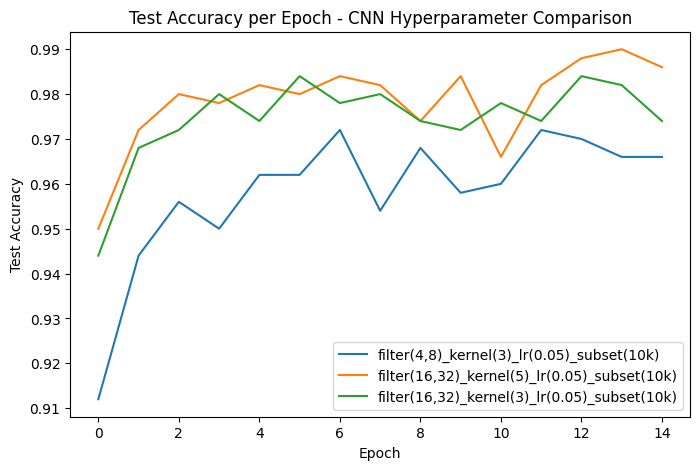

In [61]:
plt.figure(figsize=(8,5))
for name, hist in experiments.items():
    plt.plot(hist["test_acc"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.title("Test Accuracy per Epoch - CNN Hyperparameter Comparison")
plt.show()

# Training the Neural Network on the same 10000 subset in order to make a fair comparison between the NN and CNN

In [62]:
N = 10000 

_, hist_10k = train_nn(
    X_train[:N], Y_train[:N], y_train[:N], X_test, y_test,
    hidden_sizes=[128], activation="relu", init_method="he",
    lr=0.1, epochs=10, batch_size=50
)

print(f"Test Accuracy (NN, 10k subset): {hist_10k['test_acc'][-1]:.4f}")

Epoch 1/10: loss=0.6566, train_acc=0.8962, test_acc=0.8872
Epoch 2/10: loss=0.3281, train_acc=0.9255, test_acc=0.9103
Epoch 3/10: loss=0.2689, train_acc=0.9359, test_acc=0.9193
Epoch 4/10: loss=0.2330, train_acc=0.9455, test_acc=0.9258
Epoch 5/10: loss=0.2054, train_acc=0.9494, test_acc=0.9273
Epoch 6/10: loss=0.1817, train_acc=0.9515, test_acc=0.9291
Epoch 7/10: loss=0.1599, train_acc=0.9626, test_acc=0.9362
Epoch 8/10: loss=0.1423, train_acc=0.9645, test_acc=0.9346
Epoch 9/10: loss=0.1287, train_acc=0.9731, test_acc=0.9399
Epoch 10/10: loss=0.1135, train_acc=0.9757, test_acc=0.9396
Test Accuracy (NN, 10k subset): 0.9396


## Conclusion

Purpose of this notebook was to investigate how architecture and hyperparameter choices affect learning in a neural network, rather than just report a single trained model, and the sweeps across learning rate, activation, initialization, width, and depth each showed a different kind of effect.

**What mattered most:** Learning rate and activation function had the largest, clearest impact. Dropping the learning rate from 0.1 to 0.01 cost nearly 3.5 points of test accuracy within the same 10 epochs - not because the network was unstable, but because it had not converged yet. Sigmoid activation showed a similar but independent effect. It was 2.6 points behind ReLU, consistently across every epoch, consistent with the vanishing-gradient behavior sigmoid is known for.

**What mattered less than expected:** Depth and width, past a point, made almost no difference. Three hidden layers performed the same as one (97.86% vs 97.88%). Width plateaued past 128 neurons: 512 neurons gave us only 0.2 extra points over 128 despite quadrupling the layer size. For a task as well-separated as MNIST digit classification, a single 128-unit hidden layer already has enough capacity; the bottleneck here is not the architecture, it is the optimization 
settings (learning rate, activation) that actually controlled how well that capacity got used.

**NN vs CNN:** The NN trained on the full 60,000-image training set achieved 97.86% test accuracy. The CNN used the same basic ideas but added convolution and max-pooling. It was tested on a smaller 10,000-image subset, and the best setup (16/32 filters with a 5×5 kernel) achieved 98.60% accuracy. This was interesting because the CNN got a better accuracy even though it was trained on 6 times less data. When the NN was also trained on the same 10,000-image subset, its accuracy dropped to 93.96%. The CNN did not drop as much, which shows that CNNs are better at working with images when there is less training data. The main reason is that CNNs are designed to work with the spatial structure of images. Convolution looks at nearby pixels together, while pooling helps the model handle small changes in the position of objects. A normal NN does not have this built in, so it has to learn these patterns from the training data itself. This experiment showed that the CNN's structure can help it get better results even with much less data.

**Overall:** The most important factors for this task were using the right type of model, choosing a suitable learning rate, and using a good activation function. The CNN performed better than the NN because it is better suited for image data. The learning rate also had a big effect on whether the model was able to learn properly within the given training time. ReLU also worked better because it does not have the same saturation problem as sigmoid or tanh. On the other hand, changing the depth or width of the network had a smaller effect once the model already had a reasonably sized hidden layer.
